In [1]:
##### Import #######

import random
import numpy as np
import asymmetree.treeevolve as te
import networkx as nx
import copy
import matplotlib.pyplot as plt

from asymmetree.visualization.tree_vis import visualize, assign_colors
from bmg_fun import convert_to_nx
from MISC_Functions import visualize_BCN, visualize_bmg, visualize_network
from bmg_Tony import bmg
from BCEA import BCEA

In [2]:
def generateTree(seed:int = None, nSpecies:int = 2):

    if seed:
        # Setze den Seed für Pythons Standard-Zufallsfunktionen
        random.seed(seed)
        # Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
        np.random.seed(seed)
    speciesTree = te.species_tree_n_age(
        age = 1.0,
        n = nSpecies
        #, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
    )
    # gene tree
    T = te.dated_gene_tree(
        speciesTree, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
    )
    # prune all loss branches and the planted root
    geneTree = te.prune_losses(T)
    
    return speciesTree, geneTree

34915


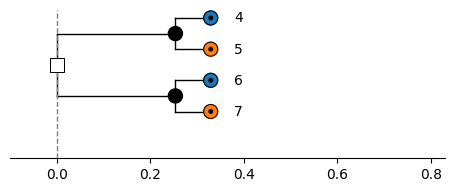

In [3]:
seed = random.randint(0,100000)
print(seed)
speciesTree, geneTree = generateTree(seed=43 ,nSpecies=2)
# 2 Spezies, 3 leafs: seed = 76935
species_colors, gene_colors = assign_colors(speciesTree, geneTree)

# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

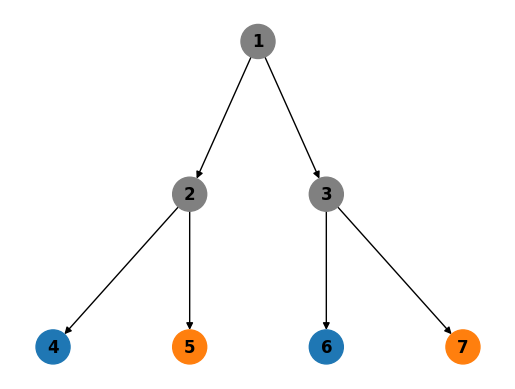

In [4]:
# convert to networkx
Tree = convert_to_nx(geneTree)
visualize_network(Tree)

In [5]:
network = copy.copy(Tree)


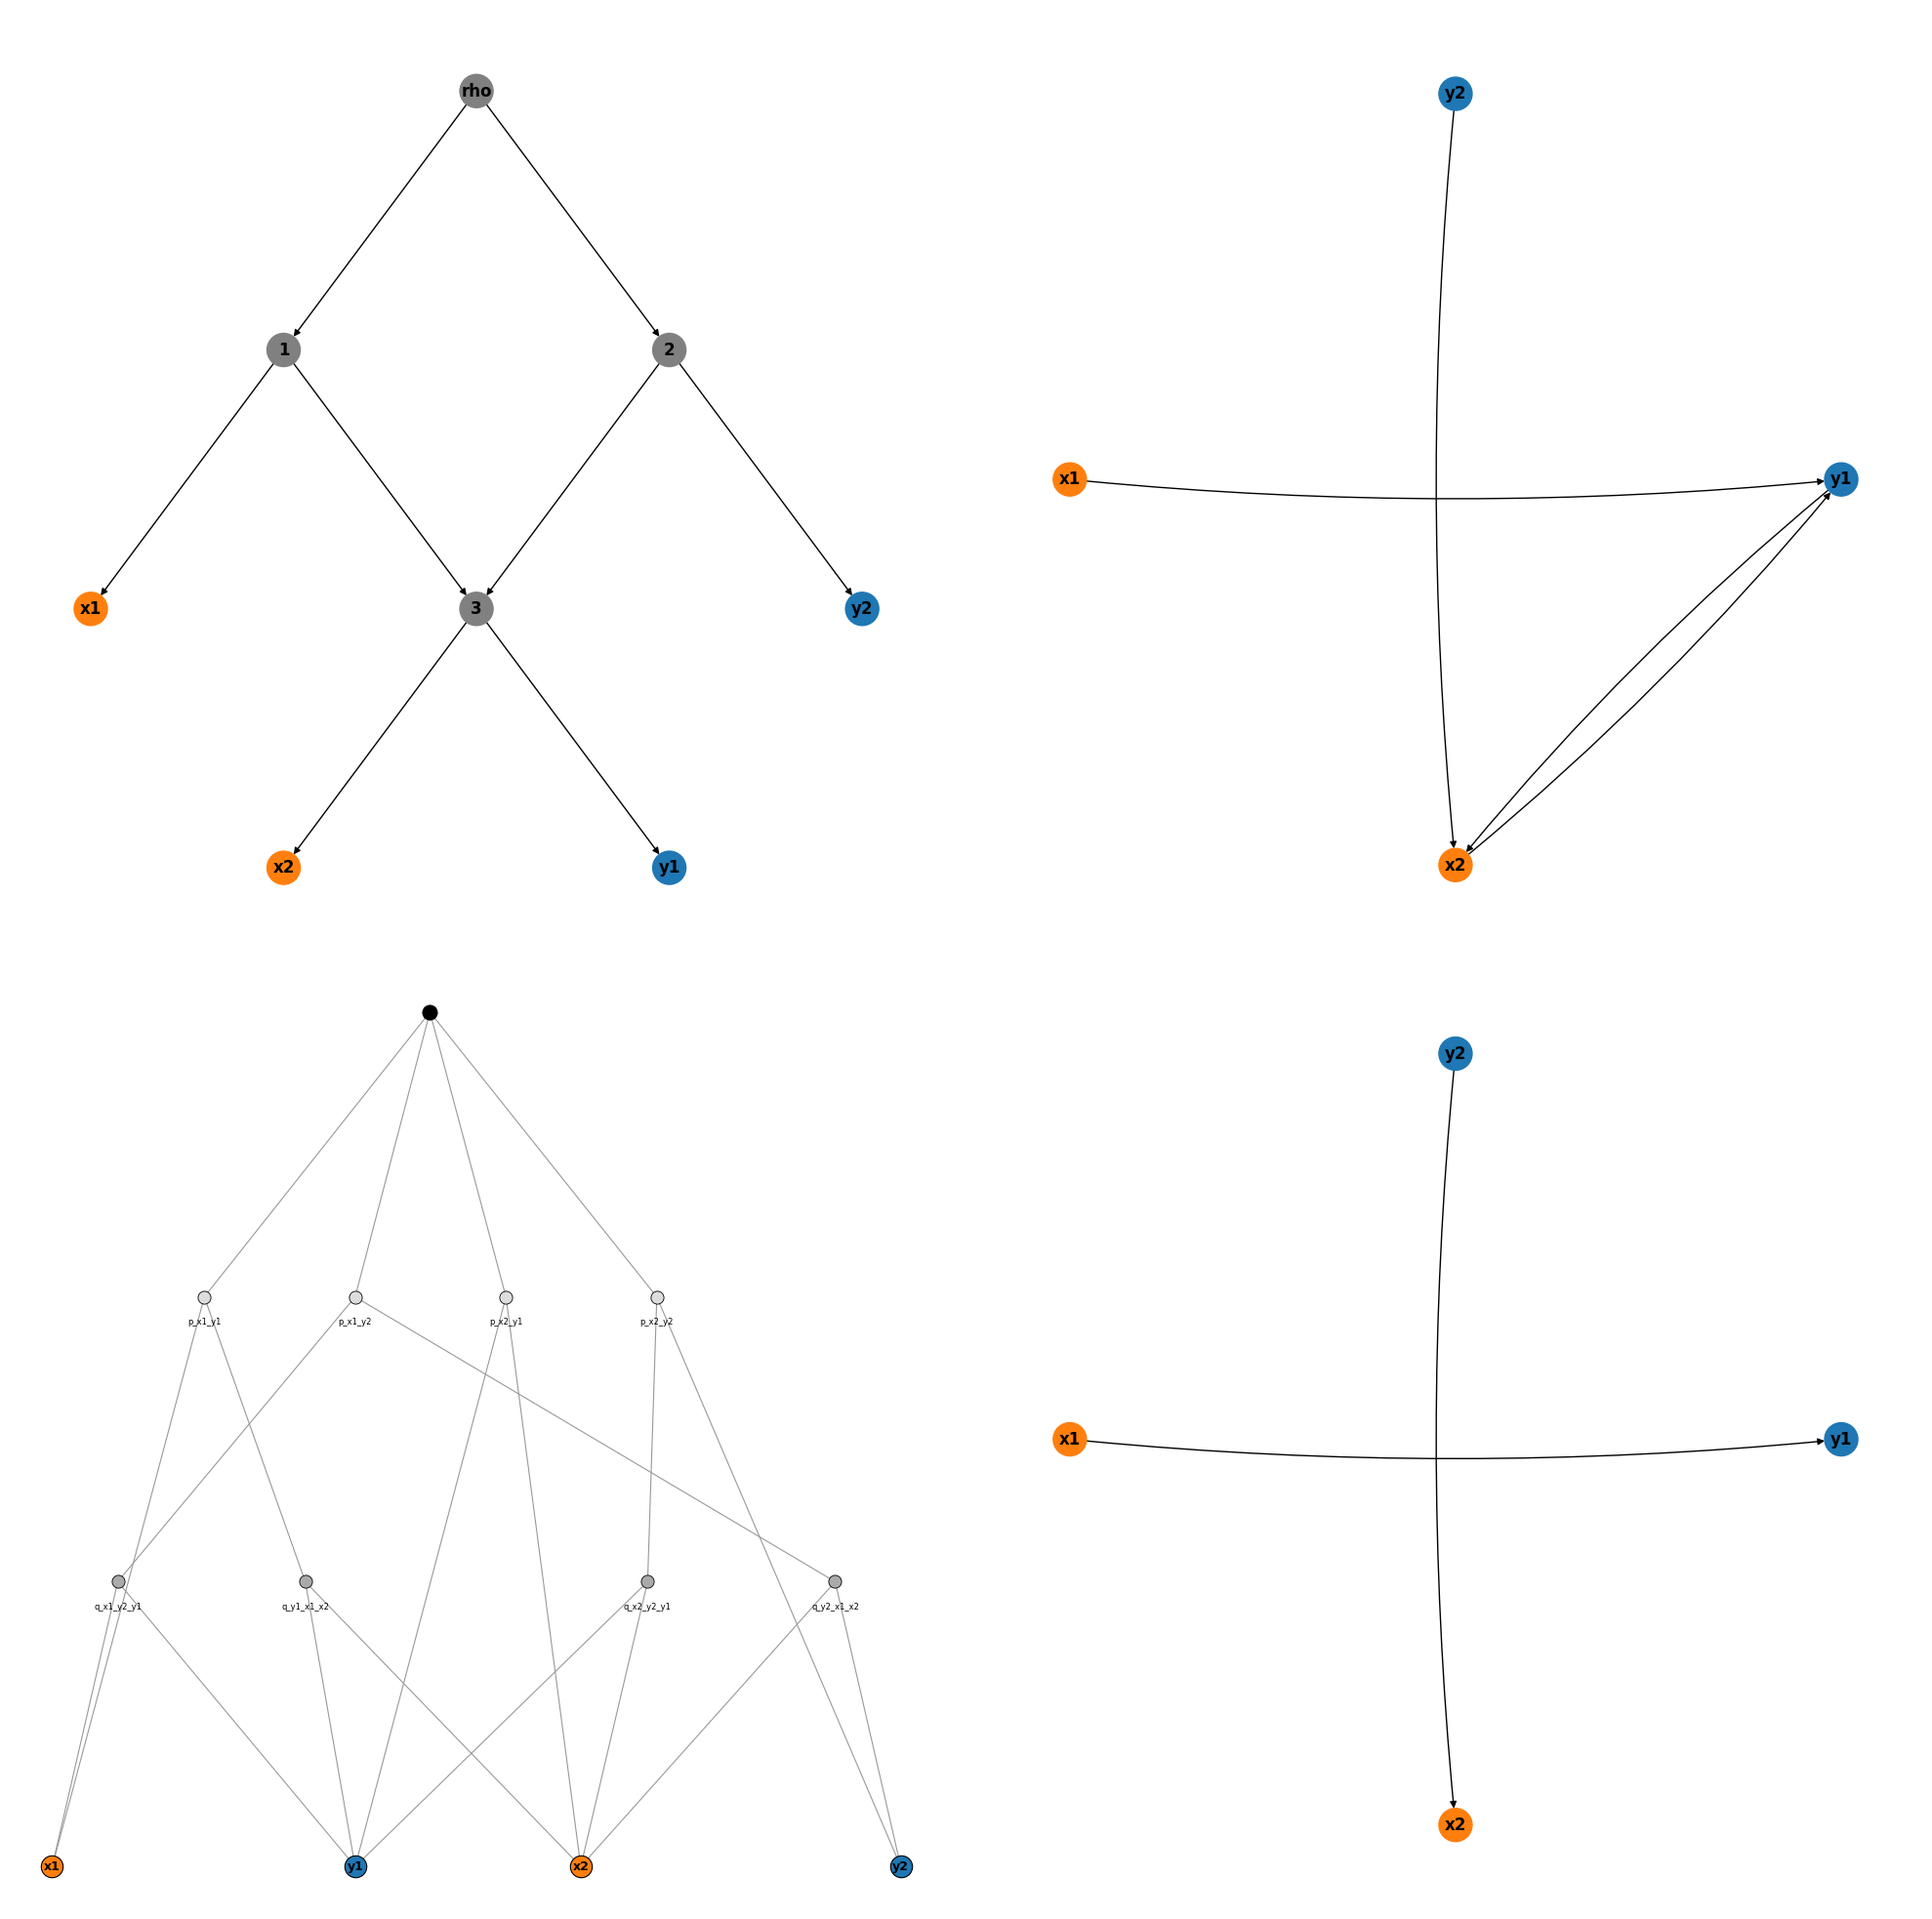

In [6]:
#########################################################################
# Gegenbeispiel für "strong BMG lässt sich immer durch BCEA darstellen" #
#########################################################################


Netz = nx.DiGraph()
Netz.add_node('rho')
Netz.add_node('1')
Netz.add_node('2')
Netz.add_node('3')
Netz.add_node('x1', color = 'red')
Netz.add_node('x2', color = 'red')
Netz.add_node('y1', color = 'blue')
Netz.add_node('y2', color = 'blue')

Netz.add_edges_from([('rho','1'),('rho','2'),('1','3'),('2','3'),('1','x1'),('3','x2'),('3','y1'),('2','y2')])


BMG = bmg(Netz, 'strong')
BC = BCEA(BMG, 'strong')
BCBMG = bmg(BC, 'strong')

fig, axes = plt.subplots(2, 2, figsize = (20,20))

visualize_network(Netz, ax = axes[0,0])
visualize_bmg(BMG, ax=axes[0,1])

visualize_BCN(BC, ax = axes [1,0])
visualize_bmg(BCBMG, ax=axes[1,1])


plt.show()